In [1]:
import os
import pandas as pd
import numpy as np
import importlib
import pickle

from Soccer_OCEL.idsse_import import get_games, load_game_data
from Soccer_OCEL.role_objects import assign_roles_multi, assign_roles
import Soccer_OCEL.utils as utils
import Soccer_OCEL.soccer_plot as plot
import Soccer_OCEL.trajectory_clustering as tc

import geopandas as gpd
import shapely.geometry as geometries
from Soccer_OCEL.soccer_plot import plot_background_ax, fastplot, plot_background, plot_trace, add_legend, add_event

from shapely.geometry import Polygon, LineString, Point

import matplotlib.pyplot as plt

In [ ]:
path='data/28196177'
games=['J03WQQ', 'J03WPY', 'J03WOH', 'J03WOY']
GDs=[]
for Game in games:
    with open(os.path.join('output','output_pkl',f"GameData_{Game}.pkl"), "rb") as f:
        GameData = pickle.load(f)
    flagged_df=tc.trajectory_anom_full_game(GameData)
    flagged_df.to_csv(os.path.join("output","output_cluster",Game+".csv"), index=False)
    GDs.append(GameData)
    

In [ ]:
path='data/28196177'
#games=get_games(path)
games=['J03WR9']
#games=['J03WQQ', 'J03WR9']#, 'J03WPY', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf
#games=['J03WQQ', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf, won games
#games=['J03WR9', 'J03WPY']#Fortuna Düsseldorf lost game
all_games=[]
for Game in games:
    with open(os.path.join('output','output_pkl',f"GameData_{Game}.pkl"), "rb") as f:
        GameData = pickle.load(f)
    GameData.format_log('ALL')
#     all_games.append(GameData.events)
# allgame_df=pd.concat(all_games).sort_values(['attribute:session','attribute:frame']).reset_index(drop=True)
# GameData=assign_roles(GameData, process_DF='TEAMSHEET')

  Downsampled 349 → 117 frames (factor=3)
  Auto-selected eps=0.2790, silhouette=0.410, clusters=4, outliers=0


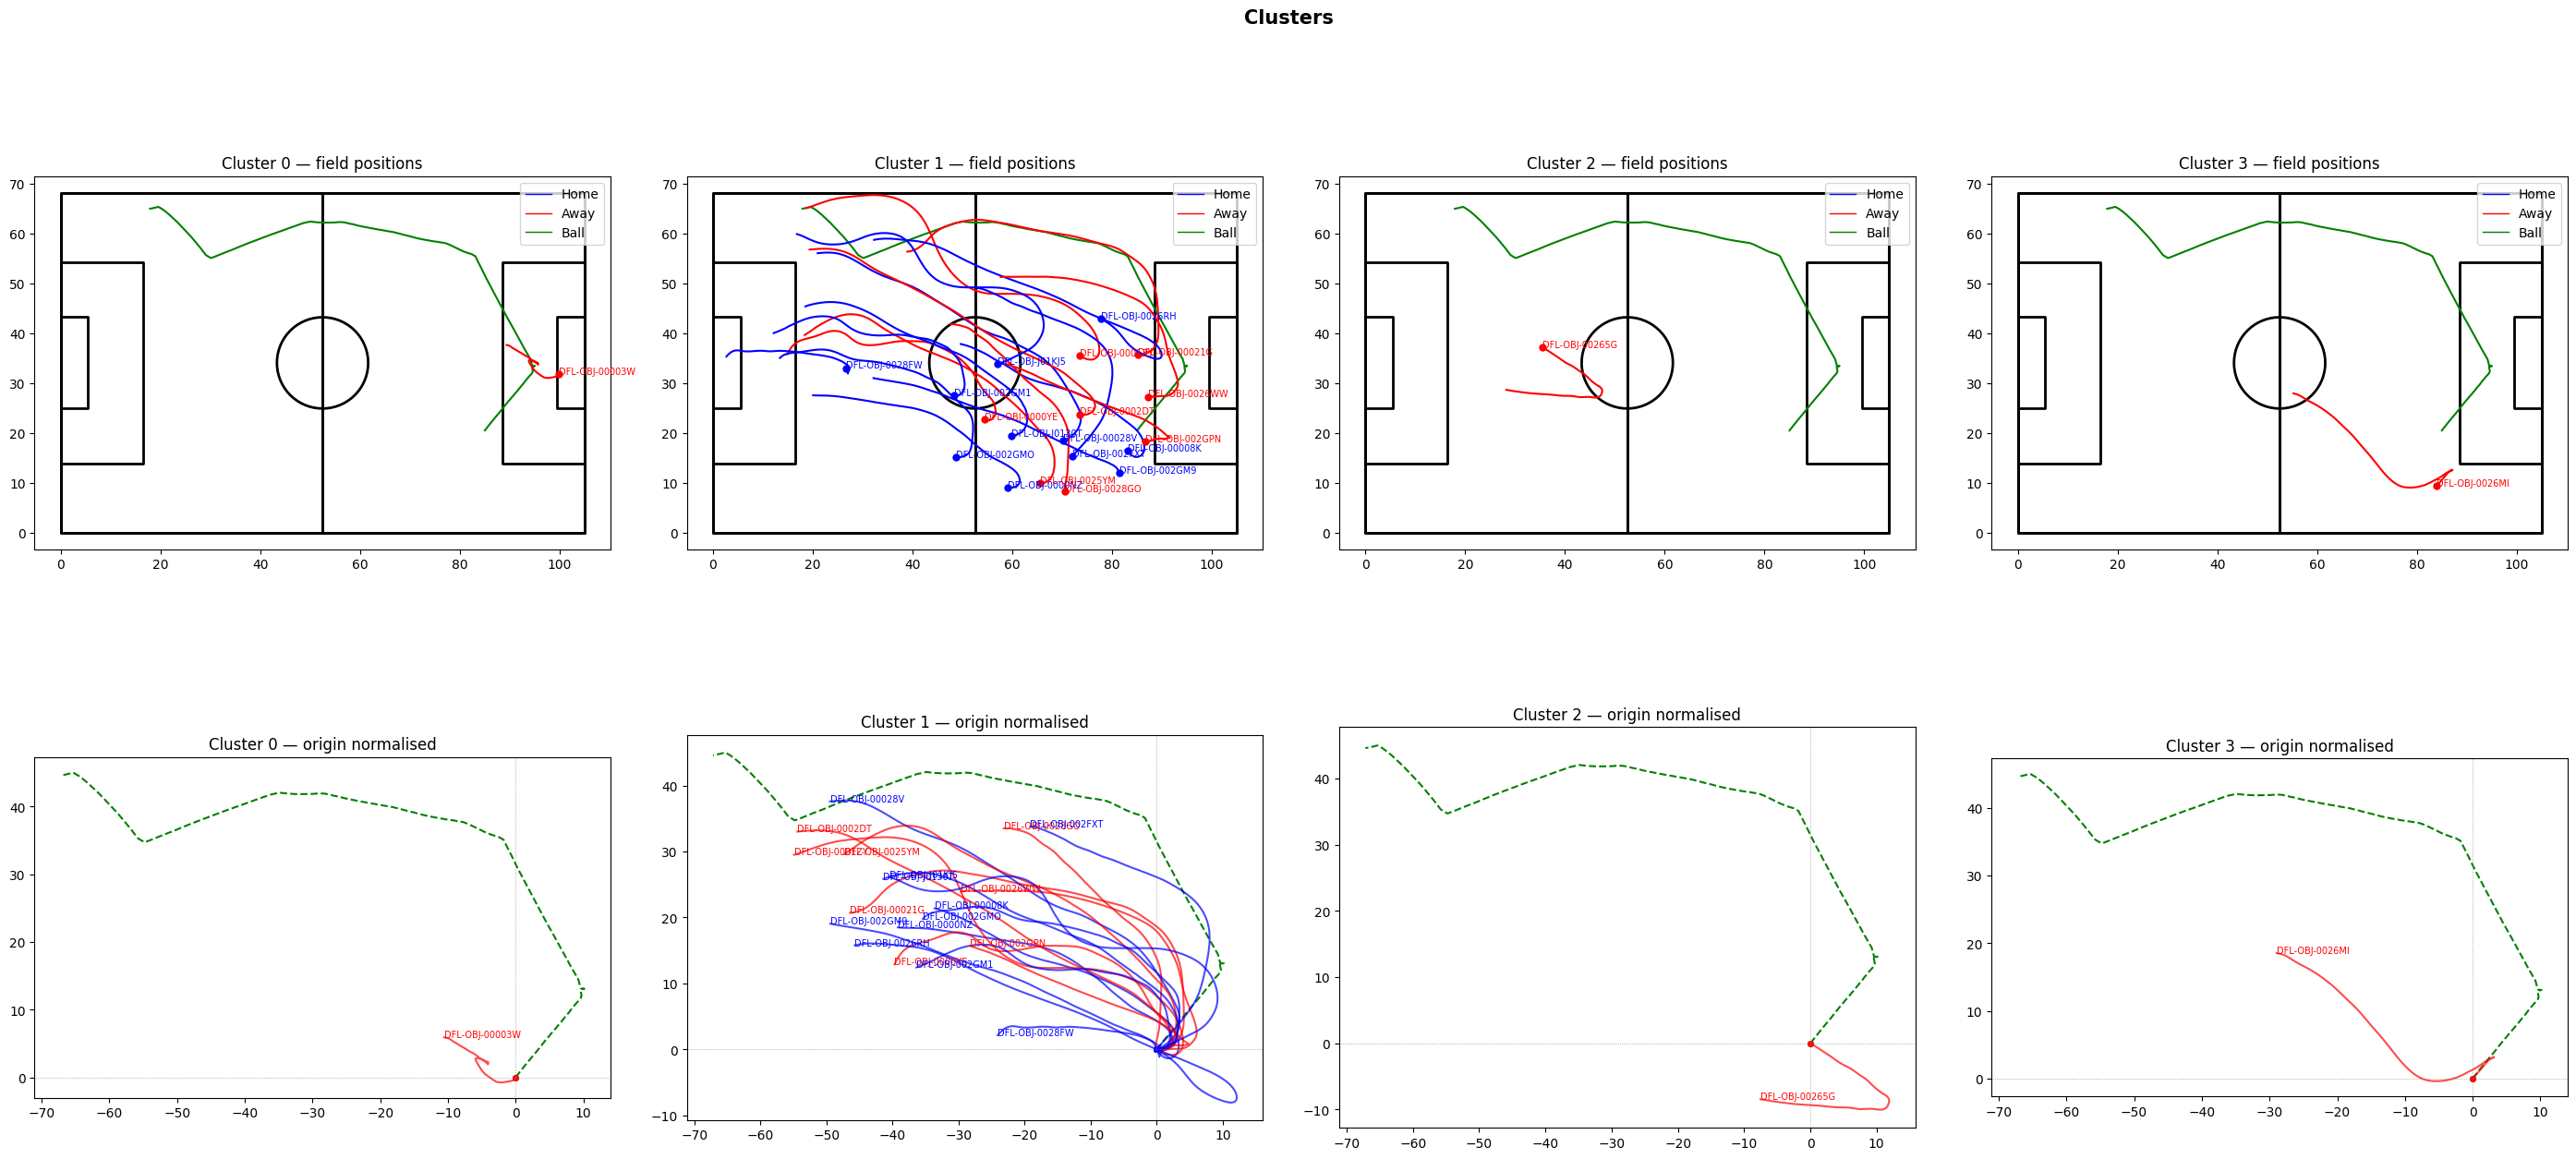


TEAM BREAKDOWN PER CLUSTER
Home_Away     Away  Home  Total
cluster_name                   
Cluster 0        1     0      1
Cluster 1        8    11     19
Cluster 2        1     0      1
Cluster 3        1     0      1

ROLE BREAKDOWN PER CLUSTER
role          Defender  Forward  Goalkeeper  Midfielder  Unknown
cluster_name                                                    
Cluster 0            0        0           1           0        0
Cluster 1            7        2           1           8        1
Cluster 2            0        0           0           1        0
Cluster 3            1        0           0           0        0

ROLE BREAKDOWN PER CLUSTER BY TEAM

  Away
  ------------------------------
role          Defender  Forward  Goalkeeper  Midfielder
cluster_name                                           
Cluster 0            0        0           1           0
Cluster 1            3        1           0           4
Cluster 2            0        0           0           1
Clust

,player,tID,team,role,cluster,is_handling
0,DFL-OBJ-00265G,DFL-CLU-00000I,Away,Midfielder,2,False
1,DFL-OBJ-0026MI,DFL-CLU-00000I,Away,Defender,3,False


In [3]:
flagged, _, _=tc.trajectory_anom_per_possession(GameData, "J03WR9_Away_2", plotting=True, breakdown_report=True)
flagged

In [3]:
GameData.events=GameData.events.sort_values(['attribute:session','attribute:frame'])
possession_ids, counts=np.unique(GameData.events['case:concept:name'], return_counts=True)
results = []
for pid, c in zip(possession_ids, counts):
    if c>1:
        print(f'Processing: {pid}')
        flagged, labels, D = tc.trajectory_anom_per_possession(GameData, pid, target_frames=125)
        if not flagged.empty:
            flagged["possessionID"] = pid
            results.append(flagged)



Processing: J03WR9_Away_10
  Downsampled 161 → 161 frames (factor=1)
  Auto-selected eps=0.3298, silhouette=0.174, clusters=2, outliers=0
Processing: J03WR9_Away_101
  Downsampled 284 → 142 frames (factor=2)
  Auto-selected eps=0.3550, silhouette=0.250, clusters=2, outliers=0
Processing: J03WR9_Away_103
  Downsampled 229 → 229 frames (factor=1)
  Auto-selected eps=0.4605, silhouette=0.256, clusters=2, outliers=0
Processing: J03WR9_Away_107
  Auto-selected eps=0.1339, silhouette=0.643, clusters=2, outliers=0
Processing: J03WR9_Away_11
  Downsampled 336 → 168 frames (factor=2)
  Auto-selected eps=0.3240, silhouette=0.409, clusters=2, outliers=0
Processing: J03WR9_Away_111
  Auto-selected eps=0.1730, silhouette=0.655, clusters=2, outliers=0
Processing: J03WR9_Away_113
  Downsampled 295 → 148 frames (factor=2)
  Auto-selected eps=0.3691, silhouette=0.084, clusters=2, outliers=0
Processing: J03WR9_Away_114
  Downsampled 307 → 154 frames (factor=2)
  Auto-selected eps=0.4728, silhouette=0.35

In [ ]:
all_flagged = pd.concat(results, ignore_index=True) if results else pd.DataFrame()
all_flagged.to_csv("output/output_cluster/J03WR9.csv", index=False)

172


In [24]:
pd.read_csv("output/output_cluster/J03WR9.csv")

,player,tID,team,role,cluster,is_handling,possessionID
0,DFL-OBJ-J01KJ5,DFL-CLU-00000P,Home,Defender,1,False,J03WR9_Away_10
1,DFL-OBJ-002GM9,DFL-CLU-00000P,Home,Defender,1,False,J03WR9_Away_103
2,DFL-OBJ-002GM1,DFL-CLU-00000P,Home,Midfielder,1,False,J03WR9_Away_107
3,DFL-OBJ-0026MI,DFL-CLU-00000I,Away,Defender,1,False,J03WR9_Away_113
4,DFL-OBJ-0025YM,DFL-CLU-00000I,Away,Midfielder,1,False,J03WR9_Away_114
...,...,...,...,...,...,...,...
412,DFL-OBJ-0000YE,DFL-CLU-00000I,Away,Forward,3,False,J03WR9_Home_86
413,DFL-OBJ-00265G,DFL-CLU-00000I,Away,Midfielder,3,False,J03WR9_Home_86
414,DFL-OBJ-0000YE,DFL-CLU-00000I,Away,Forward,2,True,J03WR9_Home_92
415,DFL-OBJ-002GM9,DFL-CLU-00000P,Home,Defender,2,False,J03WR9_Home_92


In [ ]:
report_flagged_summary(all_flagged, top_n=5)

TOP 5 MOST FLAGGED PLAYERS PER TEAM

  Away
  ------------------------------
    DFL-OBJ-0000YE (Forward): 29 times
    DFL-OBJ-00265G (Midfielder): 25 times
    DFL-OBJ-0001ZY (Midfielder): 23 times
    DFL-OBJ-0002DT (Midfielder): 18 times
    DFL-OBJ-0026MI (Defender): 17 times

  Home
  ------------------------------
    DFL-OBJ-0000NZ (Defender): 35 times
    DFL-OBJ-002GMO (Defender): 30 times
    DFL-OBJ-J01KJ5 (Defender): 28 times
    DFL-OBJ-002FXT (Unknown): 21 times
    DFL-OBJ-002GM1 (Midfielder): 21 times


TOP 5 MOST FLAGGED ROLES PER TEAM

  Away
  ------------------------------
    Midfielder: 96 times
    Defender: 53 times
    Forward: 30 times
    Goalkeeper: 10 times

  Home
  ------------------------------
    Defender: 114 times
    Midfielder: 58 times
    Unknown: 21 times
    Forward: 18 times
    Goalkeeper: 17 times

TOP 5 POSSESSIONS WITH MOST FLAGGED PLAYERS

  J03WR9_Away_142: 11 flagged players
    Composition:
      Away (4): Midfielderx3, Forwardx1
    

here show that home team defender frequently take uncommon action whereas away midfield is the most frequent to take uncommone actions. 

-see if this is correlated to win/loss--> in disadvantage some position takes more action

-we could compare to findings of pm

In [ ]:
df=GameData.events.query('`case:concept:name`=="J03WR9_Away_2"')
df['attribute:frame']=df['attribute:frame'].astype(int)
#df=df[df["geometry"].isna()]
start_frame, end_frame, session=np.min(df['attribute:frame']),np.max(df['attribute:frame']),np.unique(df['attribute:session'])[0]
print(start_frame, end_frame, session)
ball=GameData.positions.query('`Frame`>=@start_frame & `Frame`<@end_frame & Session==@session')
extract_ball=np.unique(ball['Player'])[0]
ball=ball.query('Player==@extract_ball')[['ball_x','ball_y', 'Frame']]
ball.rename(columns={'ball_x':'x','ball_y':'y'}, inplace=True)
# ball_gdf = gpd.GeoDataFrame(
#     ball,
#     geometry=gpd.points_from_xy(ball["x"], ball["y"])
# )
# ball_line = gpd.GeoDataFrame(
#     geometry=[LineString(zip(ball["x"], ball["y"]))]
# )
# h_df=df.query('`attribute:team`=="Home"')
# a_df=df.query('`attribute:team`=="Away"')
# h_df=gpd.GeoDataFrame(df.query('`attribute:team`=="Home"'),
#     geometry=GameData.events['trajectory'])
# a_df=gpd.GeoDataFrame(df.query('`attribute:team`=="Away"'),
#     geometry=GameData.events['trajectory'])

197 546 1


/var/folders/c4/5rcttgt14hj_p3bnfsdmbmkr0000gn/T/ipykernel_33891/1060154606.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['attribute:frame']=df['attribute:frame'].astype(int)


In [26]:
pass_sub=df.query('ball.notna()')
pass_sub = pass_sub[pass_sub["concept:name"].str.endswith(("Pass", "Cross", "Received", "Intercepted"), na=False)]
handling_players=np.unique(pass_sub['Player'])

In [4]:
session_df=GameData.positions[GameData.positions["Session"] == session]
session_df = session_df.query('Frame<@end_frame & Frame>=@start_frame')
session_df = session_df.sort_values(["Player", "Frame"])

traj_df = (
    session_df.groupby(["Player","Team"])
      .apply(lambda g: LineString(zip(g["x"], g["y"])))
      .reset_index(name="geometry")
)

gdf = gpd.GeoDataFrame(traj_df, geometry="geometry")
home = gdf[gdf["Team"] == "Home"]
away = gdf[gdf["Team"] == "Away"]

/var/folders/c4/5rcttgt14hj_p3bnfsdmbmkr0000gn/T/ipykernel_33891/3143452474.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: LineString(zip(g["x"], g["y"])))


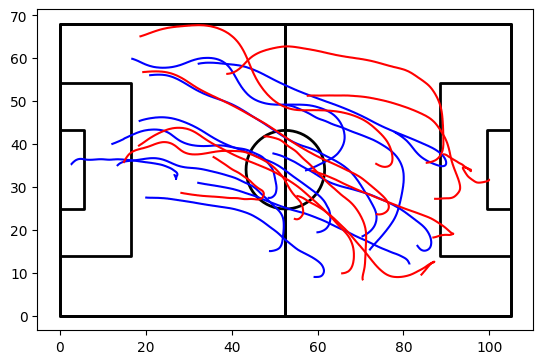

In [7]:
fig, ax= plt.subplots()
plot.plot_background_ax(ax)
plot.plot_trace(home, ax, 'blue')
plot.plot_trace(away, ax, 'red')


In [ ]:
players = {
    pid: grp.sort_values("Frame")[["x", "y"]].values
    for pid, grp in session_df.groupby("Player")
}
ball_ar = ball.sort_values("Frame")[["x", "y"]].values


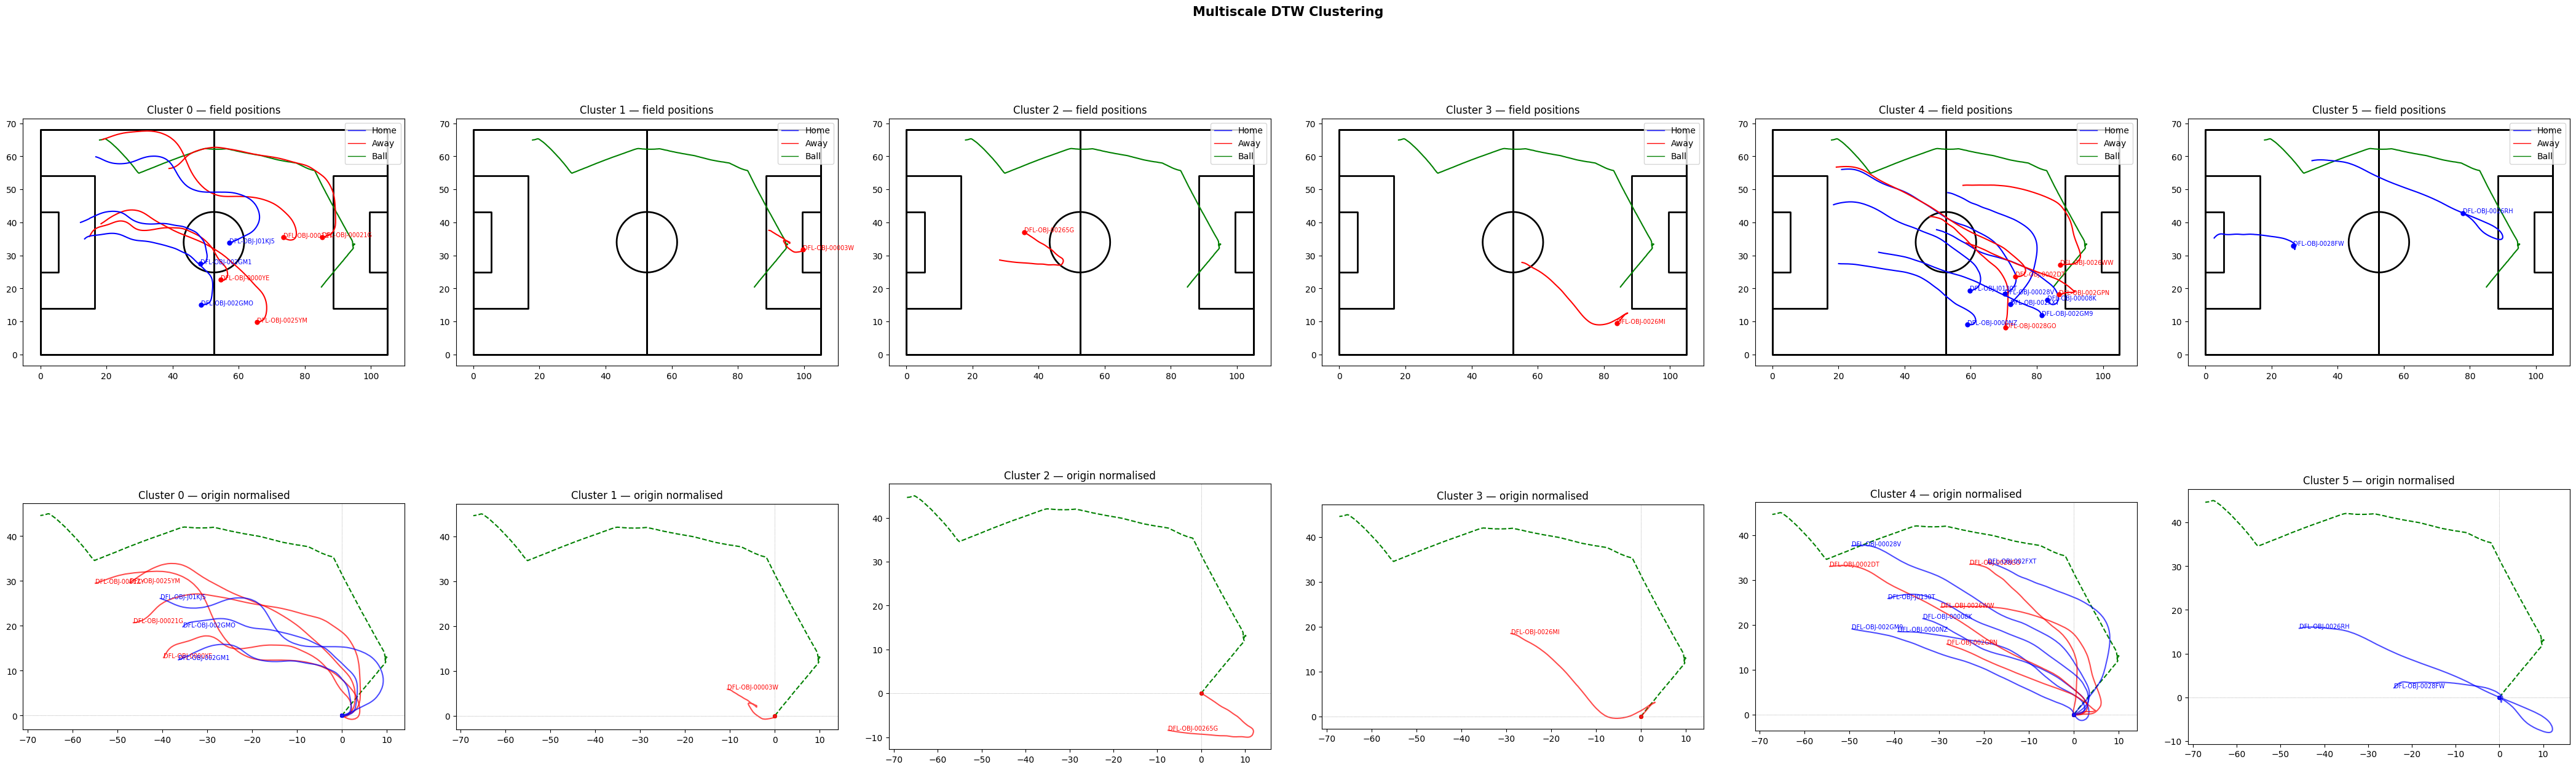

In [ ]:
labels, D, ids = tc.cluster_multivariate(players, ball_ar, n_clusters=6, weights=np.array([1,0]))
team_map = session_df.drop_duplicates("Player").set_index("Player")["Team"].to_dict()

fig = tc.plot_clusters(players, ball_ar, labels, team_map,
                    title="Multivariate DTW Clustering")
plt.show()

  Auto-selected eps=0.1220, silhouette=0.352, clusters=5, outliers=0


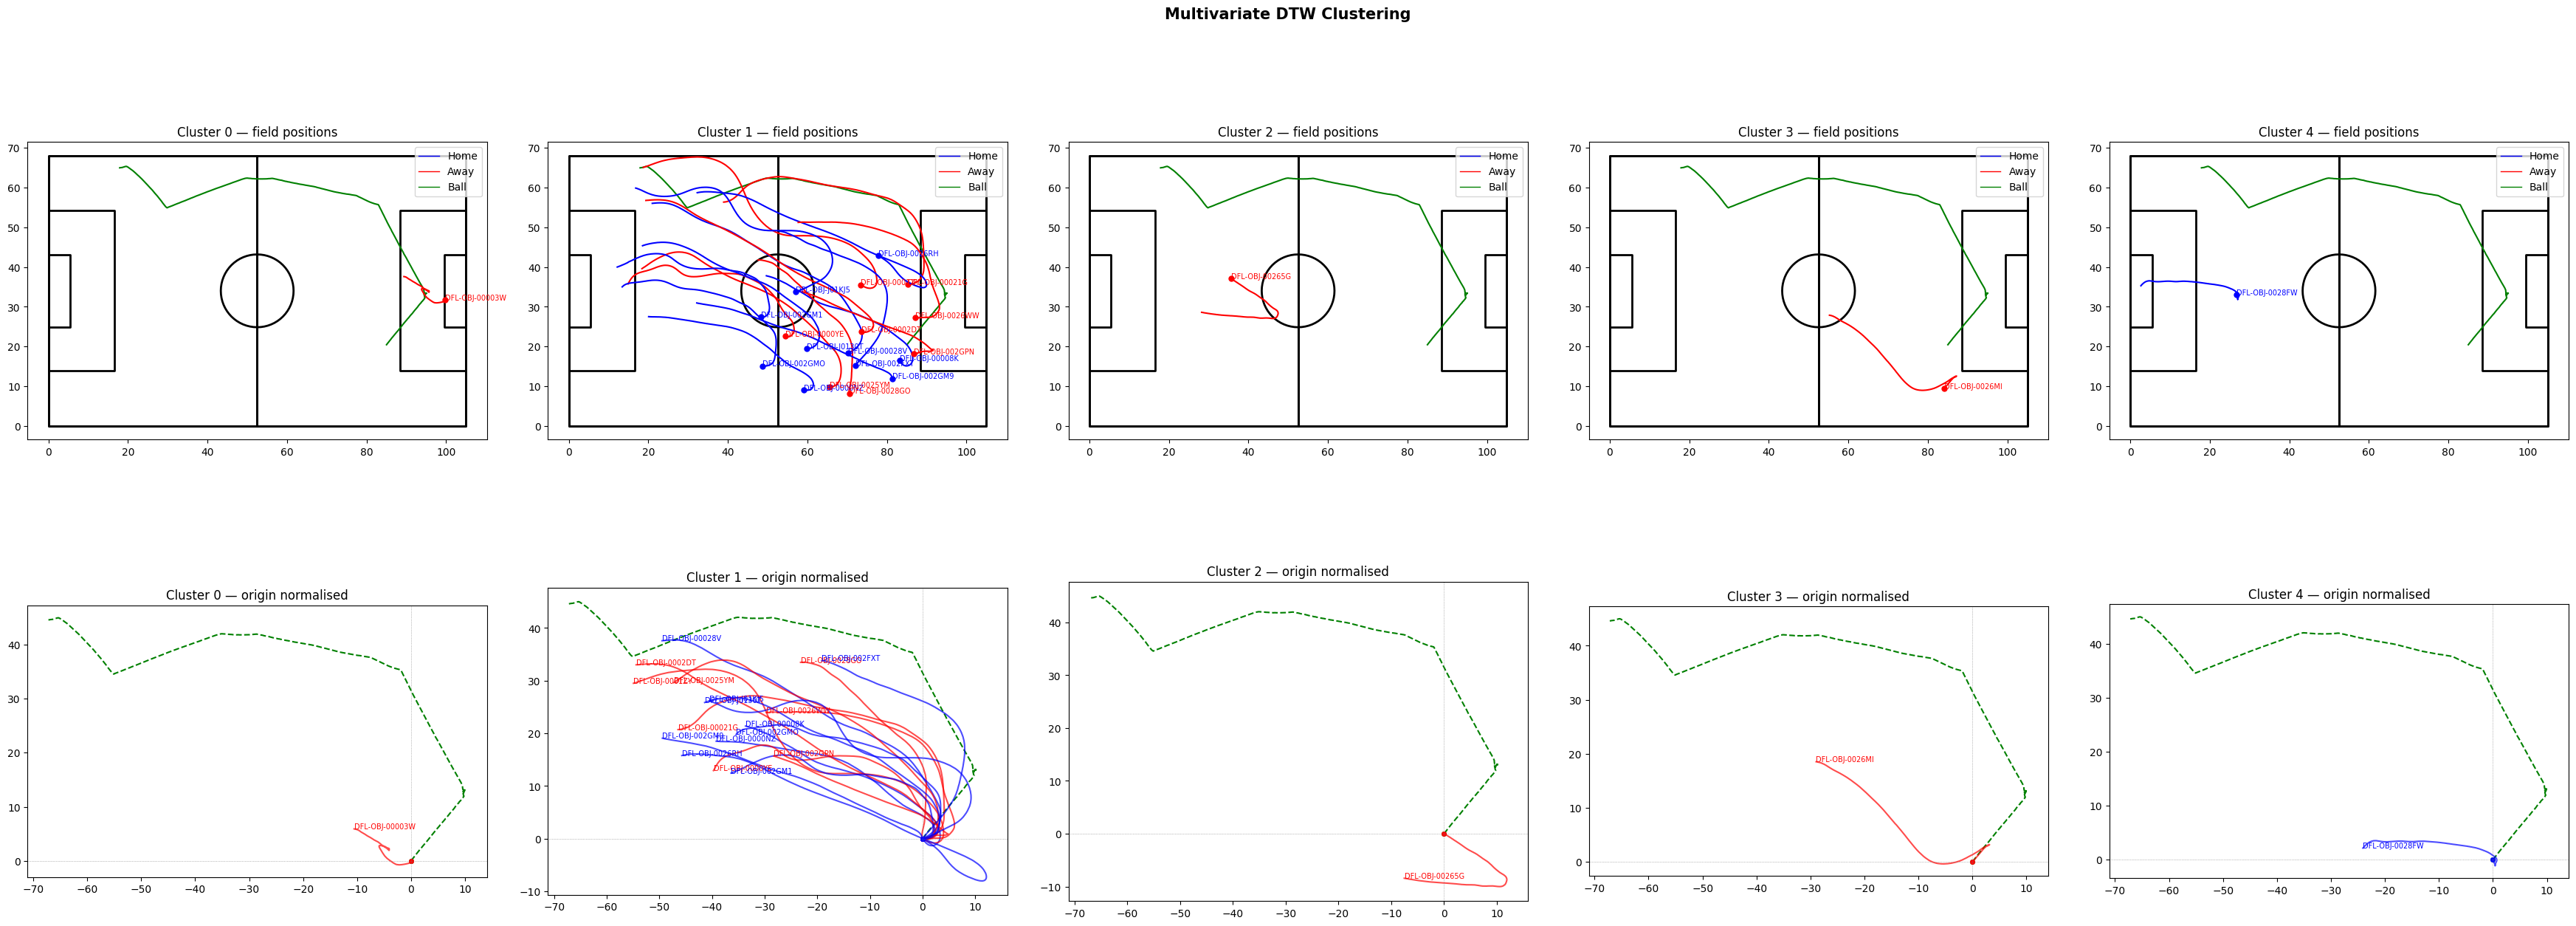

In [38]:
def get_multivariate_distance_matrix(players: dict[str, np.ndarray],
                                      ball: np.ndarray,
                                      weights: np.ndarray = None) -> tuple:
    if weights is None:
        weights = np.array([0.5, 0.5])

    mv_signals = tc.build_multivariate_signals(players, ball)
    return tc.build_multivariate_distance_matrix(mv_signals, weights)
ids_mv, D_mv = get_multivariate_distance_matrix(players, ball, weights=np.array([0.5, 0.5]))
def normalise_distance_matrix(D: np.ndarray) -> np.ndarray:
    max_d = D.max()
    if max_d == 0:
        return D
    return D / max_d
D_norm = normalise_distance_matrix(D)
labels_db = tc.auto_cluster_dbscan(D_norm, ids, min_samples=1)
team_map = session_df.drop_duplicates("Player").set_index("Player")["Team"].to_dict()
fig = tc.plot_clusters(players, ball_ar, labels_db, team_map,
                    title="Multivariate DTW Clustering")
plt.show()

In [39]:
analyse_clusters(labels_db, GameData.team_sheets_df)


TEAM BREAKDOWN PER CLUSTER
Home_Away     Away  Home  Total
cluster_name                   
Cluster 0        1     0      1
Cluster 1        8    10     18
Cluster 2        1     0      1
Cluster 3        1     0      1
Cluster 4        0     1      1

ROLE BREAKDOWN PER CLUSTER
role          Defender  Forward  Goalkeeper  Midfielder  Unknown
cluster_name                                                    
Cluster 0            0        0           1           0        0
Cluster 1            7        2           0           8        1
Cluster 2            0        0           0           1        0
Cluster 3            1        0           0           0        0
Cluster 4            0        0           1           0        0

ROLE BREAKDOWN PER CLUSTER BY TEAM

  Away
  ------------------------------
role          Defender  Forward  Goalkeeper  Midfielder
cluster_name                                           
Cluster 0            0        0           1           0
Cluster 1           

In [40]:
flagged = flag_players(labels_db, GameData.team_sheets_df, handling_players)

FLAGGED PLAYERS (moving differently)

  Cluster 0: skipped (goalkeepers only)

  Cluster 2 (1 players):
    DFL-OBJ-00265G — Away, Midfielder

  Cluster 3 (1 players):
    DFL-OBJ-0026MI — Away, Defender

  Cluster 4: skipped (goalkeepers only)

  Flagged player list: ['DFL-OBJ-00265G', 'DFL-OBJ-0026MI']


